### Can we accurately predict Airbnb prices using listing characteristics?

### Which factors are the most important drivers of Airbnb prices?

### Do different neighborhoods have distinct pricing patterns?

In [76]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
import numpy as np

In [27]:
lists = pd.read_csv("listings.csv.gz")
lists.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [61]:
lists = lists.fillna(0)

In [55]:
features = [
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "review_scores_rating"
]

In [84]:
lists = lists[lists['price'] > 0]
df = lists[features]
df = df.fillna(0)
df

,accommodates,bedrooms,beds,bathrooms,minimum_nights,availability_365,number_of_reviews,review_scores_rating
0,1,1.0,1.0,1.0,30,177,161,4.60
1,2,1.0,2.0,3.0,2,327,220,4.73
3,8,3.0,3.0,2.0,30,178,98,4.79
4,4,1.0,2.0,1.0,2,221,1139,4.93
5,3,2.0,3.0,1.0,30,364,64,4.54
...,...,...,...,...,...,...,...,...
6991,2,1.0,1.0,1.5,1,364,0,0.00
6992,2,1.0,1.0,1.5,1,364,0,0.00
6993,2,1.0,1.0,1.0,3,364,0,0.00
6994,2,1.0,1.0,1.0,30,365,0,0.00


In [66]:
lists["price"] = (
    lists["price"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)

In [79]:
import numpy as np

price = lists["price"] 

print("min price:", price.min())
print("num <= 0:", (price <= 0).sum())
print("num NaN:", price.isna().sum())
print("top 5 largest:", price.sort_values(ascending=False).head())

min price: 0.0
num <= 0: 775
num NaN: 0
top 5 largest: 4968    50039.0
4966    50039.0
4973    50037.0
4974    50037.0
4975    50037.0
Name: price, dtype: float64


In [81]:
lists = lists[lists["price"] > 0]
p99 = lists["price"].quantile(0.99)
lists = lists[lists["price"] <= p99]

y: price
x: room_type, minimum_night,  neighbourhood, neighbourhood_group

In [85]:
X = df
# y = lists["price"]
y = np.log(lists["price"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [86]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [88]:
y_pred = rf.predict(X_test)

In [89]:
rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse)

RMSE: 0.3716001740329752


In [92]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(15)

bedrooms                0.363817
accommodates            0.158623
availability_365        0.133528
number_of_reviews       0.099224
bathrooms               0.081924
review_scores_rating    0.074777
minimum_nights          0.062677
beds                    0.025430
dtype: float64

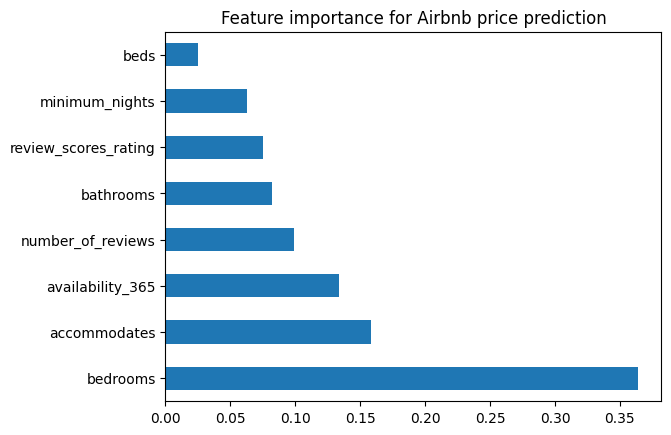

In [93]:
import matplotlib.pyplot as plt

importance.head(10).plot(kind="barh")
plt.title("Feature importance for Airbnb price prediction")
plt.show()